# Double-diSPIM Processing Pipeline

This notebook processes raw double-diSPIM data through:
1. **Load & Parse Metadata**: Extract acquisition parameters and timing information
2. **Load Temporally Aligned Stacks**: Load all 4 cameras with proper temporal alignment
3. **Deskew**: Remove 45° shear from light sheet imaging for all 4 cameras
4. **Save**: Save all 4 deskewed volumes for interactive 3D alignment
5. **Visualize**: Display various camera combinations to understand the data

## System Geometry

- **Alpha Arm (Top)**: Two cameras viewing from above
- **Beta Arm (Bottom)**: Two cameras viewing from below
- Each camera captures 45° sheared slices that need deskewing
- Cameras are sequential (not simultaneous), so temporal alignment accounts for timing offsets
- After deskewing, volumes will be aligned interactively using a 3D visualization tool (Napari)

## Section 1: Setup and Imports

In [1]:
# NumPy 2.0 compatibility
import numpy as np
if not hasattr(np, 'unicode_'):
    np.unicode_ = np.str_

import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import consolidated utility functions
from dispim_utils import (
    # Metadata and discovery
    parse_metadata,
    discover_acquisitions,
    extract_spatial_info,
    calculate_temporal_alignment,
    # Data loading with temporal alignment
    load_temporally_aligned_stacks,
    # Deskewing
    deskew_stack,
    # Save/load - temporally aligned
    save_temporally_aligned_stacks,
    load_temporally_aligned_stacks_from_file,
    check_temporally_aligned_exists,
    # Save/load - deskewed
    save_deskewed_stack,
    load_deskewed_stack,
    check_deskewed_exists,
    get_deskewed_paths,
    # Visualization
    create_camera_overlay,
    create_stitched_camera_view,
)

# Set up matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Discover and Select Acquisition

In [ ]:
# Configuration: Apply CLAHE preprocessing programmatically
# If True, applies Contrast Limited Adaptive Histogram Equalization to each channel
# This can improve image quality. To use preprocessed data, replace the .ome.tif
# files in the dataset folders with your enhanced versions.
APPLY_CLAHE = False

# Discover acquisitions
acquisitions = discover_acquisitions('./datasets')
print(f"Found {len(acquisitions)} acquisition pairs:")
for i, acq in enumerate(acquisitions):
    print(f"  {i+1}. {acq['condition']}/{acq['run']}: alpha={acq['alpha_path'].name}, beta={acq['beta_path'].name}")

# Select acquisition to process
ACQUISITION_INDEX = 7

if len(acquisitions) > ACQUISITION_INDEX:
    selected_acq = acquisitions[ACQUISITION_INDEX]
    print(f"\nSelected: {selected_acq['condition']}/{selected_acq['run']}")
else:
    print(f"Error: Acquisition index {ACQUISITION_INDEX} not available")
    selected_acq = None

Found 9 acquisition pairs:
  1. 10msec_worm/I: alpha=beads_alpha_worm2_4, beta=beads_beta_worm2_4
  2. 1msec_worm/I: alpha=beads_alpha_worm2, beta=beads_beta_worm2
  3. 1msec_worm/II: alpha=beads_alpha_worm2_1_1, beta=beads_beta_worm2_1_1
  4. 200msec_worm/I: alpha=beads_alpha_worm2, beta=beads_beta_worm2
  5. 200msec_worm/II: alpha=beads_alpha_worm2_1, beta=beads_beta_worm2_1
  6. 200msec_worm/III: alpha=beads_alpha_worm2_2, beta=beads_beta_worm2_2
  7. 200msec_worm/IV: alpha=beads_alpha_worm2_3, beta=beads_beta_worm2_3
  8. 20msec_worm/I: alpha=beads_alpha_worm2_2_1, beta=beads_beta_worm2_2_1
  9. Worm1_starved_adult_SWF1188/I: alpha=worm_alpha, beta=worm_beta

Selected: 20msec_worm/I
  Using raw data (no enhanced versions found)


## Section 3: Load and Parse Metadata

In [ ]:
if selected_acq:
    # Load metadata
    print("Loading metadata...")
    alpha_meta = parse_metadata(selected_acq['alpha_metadata'])
    beta_meta = parse_metadata(selected_acq['beta_metadata'])
    
    # Extract key parameters
    spatial_info = extract_spatial_info(alpha_meta, beta_meta)
    temporal_info = calculate_temporal_alignment(alpha_meta, beta_meta)
    
    pixel_size_um = spatial_info['pixel_size_um']['average']
    z_step_um = spatial_info['z_step_um']['average']
    
    print(f"\nProcessing parameters:")
    print(f"  Pixel size: {pixel_size_um:.4f} μm")
    print(f"  Z-step: {z_step_um:.4f} μm")
    print(f"  Light sheet angle: 45° (standard for diSPIM)")
    
    print(f"\nTemporal alignment:")
    print(f"  Alpha cameras simultaneous: {temporal_info['alpha_cameras_simultaneous']}")
    print(f"  Beta cameras simultaneous: {temporal_info['beta_cameras_simultaneous']}")
    print(f"  Alpha cam0 (Path A) offset: {temporal_info['alpha_cam0_offset_ms']:.2f} ms")
    print(f"  Alpha cam1 (Path B) offset: {temporal_info['alpha_cam1_offset_ms']:.2f} ms")
    print(f"  Beta cam0 (Path A) offset: {temporal_info['beta_cam0_offset_ms']:.2f} ms")
    print(f"  Beta cam1 (Path B) offset: {temporal_info['beta_cam1_offset_ms']:.2f} ms")
    
    # Configuration for saving
    OUTPUT_DIR = Path('./processed_output')
    FORCE_RETEMPORAL_ALIGN = False  # Set to True to force re-temporal alignment
    FORCE_REDESKEW = False  # Set to True to force re-deskewing
    
    # Create acquisition name for file paths
    acquisition_name = f"{selected_acq['condition']}_{selected_acq['run']}"
else:
    print("No acquisition selected")
    alpha_meta = None
    beta_meta = None
    OUTPUT_DIR = None
    acquisition_name = None

Loading metadata...

Processing parameters:
  Pixel size: 0.1220 μm
  Z-step: 0.7000 μm
  Light sheet angle: 45° (standard for diSPIM)

Temporal alignment:
  Alpha cameras simultaneous: False
  Beta cameras simultaneous: False
  Alpha camera offset: 1.00 ms
  Beta camera offset: 1.00 ms


## Section 4: Load Temporally Aligned Stacks

Load all 4 camera stacks with proper temporal alignment. Since cameras are sequential,
each camera captures slices at slightly different times. This function interpolates
all cameras to a common time grid for temporal matching.

In [4]:
if selected_acq:
    print("=" * 70)
    print("LOADING TEMPORALLY ALIGNED STACKS")
    print("=" * 70)
    
    # Check if temporally aligned stacks already exist
    exists, paths, meta_path = check_temporally_aligned_exists(
        OUTPUT_DIR, acquisition_name, alpha_meta, beta_meta
    )
    
    if exists and not FORCE_RETEMPORAL_ALIGN:
        print(f"\nLoading existing temporally aligned stacks...")
        aligned_data = load_temporally_aligned_stacks_from_file(
            OUTPUT_DIR, acquisition_name, alpha_meta, beta_meta, verbose=True
        )
    else:
        # Load and interpolate temporally aligned stacks
        aligned_data = load_temporally_aligned_stacks(
            selected_acq['alpha_tiff'],
            selected_acq['beta_tiff'],
            alpha_meta,
            beta_meta,
            interpolation_method='linear',  # 'linear', 'nearest', or 'cubic'
            verbose=True,
            apply_clahe=APPLY_CLAHE  # Apply CLAHE preprocessing if enabled
        )
        
        # Always save temporally aligned stacks
        print(f"\nSaving temporally aligned stacks...")
        saved_paths = save_temporally_aligned_stacks(
            aligned_data, OUTPUT_DIR, acquisition_name, alpha_meta, beta_meta
        )
        print(f"Saved to: {OUTPUT_DIR / acquisition_name / 'temporally_aligned'}")
    
    # Extract individual camera stacks
    alpha_cam0 = aligned_data['alpha_cam0']
    alpha_cam1 = aligned_data['alpha_cam1']
    beta_cam0 = aligned_data['beta_cam0']
    beta_cam1 = aligned_data['beta_cam1']
    
    print(f"\nTemporally aligned stacks ready for deskewing!")
else:
    print("No acquisition selected")

LOADING TEMPORALLY ALIGNED STACKS
Loading Temporally Aligned Stacks

Loading raw data...
Loading OME-TIFF: datasets/20msec_worm/I/beads_alpha_worm2_2_1/beads_alpha_worm2_2_MMStack_Pos0.ome.tif
Raw data shape: (200, 2, 2304, 2304)
Data dtype: uint16
Applying CLAHE preprocessing to each channel...
CLAHE preprocessing complete.
Final data shape: (200, 2, 2304, 2304)
Loading OME-TIFF: datasets/20msec_worm/I/beads_beta_worm2_2_1/beads_beta_worm2_2_MMStack_Pos0.ome.tif
Raw data shape: (200, 2, 2304, 2304)
Data dtype: uint16
Applying CLAHE preprocessing to each channel...
CLAHE preprocessing complete.
Final data shape: (200, 2, 2304, 2304)

Raw data shapes:
  Alpha Cam0: (200, 2304, 2304)
  Alpha Cam1: (200, 2304, 2304)
  Beta Cam0: (200, 2304, 2304)
  Beta Cam1: (200, 2304, 2304)

Temporal alignment analysis:
  Time offset (beta - alpha): -2000.00 ms
  Beta started first
  Beta finished first
  Discarded 64 slices from START of beta arm
  Discarded 64 slices from END of alpha arm

Temporal a

## Section 5: Deskew All Volumes

Deskew each of the 4 camera stacks independently to remove the 45° shear.
All deskewed volumes are automatically saved.

In [5]:
if selected_acq:
    print("=" * 70)
    print("DESKEWING ALL VOLUMES")
    print("=" * 70)
    
    deskew_info = {}
    
    # Process Alpha Camera 0
    cam0_name = alpha_meta['channel_names'][0]
    exists, stack_path, meta_path = check_deskewed_exists(
        OUTPUT_DIR, acquisition_name, cam0_name, 'alpha'
    )
    
    if exists and not FORCE_REDESKEW:
        print(f"\nLoading existing deskewed Alpha Camera 0 ({cam0_name})...")
        alpha_cam0_deskewed, loaded_meta = load_deskewed_stack(stack_path)
        if loaded_meta and 'transform_info' in loaded_meta:
            deskew_info['alpha_cam0'] = loaded_meta['transform_info']
        print(f"  Loaded shape: {alpha_cam0_deskewed.shape}")
    else:
        print(f"\nDeskewing Alpha Camera 0 ({cam0_name})...")
        alpha_cam0_deskewed, info0 = deskew_stack(
            alpha_cam0, pixel_size_um, z_step_um, angle_deg=45.0
        )
        deskew_info['alpha_cam0'] = info0
        print(f"  Input shape: {info0['input_shape']}")
        print(f"  Output shape: {info0['output_shape']}")
        
        # Always save deskewed volumes
        stack_path, meta_path = get_deskewed_paths(
            OUTPUT_DIR, acquisition_name, cam0_name, 'alpha'
        )
        save_deskewed_stack(
            alpha_cam0_deskewed, stack_path,
            transform_info=info0,
            metadata={'camera': cam0_name, 'arm': 'alpha', 'pixel_size_um': pixel_size_um, 'z_step_um': z_step_um}
        )
        print(f"  Saved to: {stack_path}")
    
    # Process Alpha Camera 1
    cam1_name = alpha_meta['channel_names'][1]
    exists, stack_path, meta_path = check_deskewed_exists(
        OUTPUT_DIR, acquisition_name, cam1_name, 'alpha'
    )
    
    if exists and not FORCE_REDESKEW:
        print(f"\nLoading existing deskewed Alpha Camera 1 ({cam1_name})...")
        alpha_cam1_deskewed, loaded_meta = load_deskewed_stack(stack_path)
        if loaded_meta and 'transform_info' in loaded_meta:
            deskew_info['alpha_cam1'] = loaded_meta['transform_info']
        print(f"  Loaded shape: {alpha_cam1_deskewed.shape}")
    else:
        print(f"\nDeskewing Alpha Camera 1 ({cam1_name})...")
        alpha_cam1_deskewed, info1 = deskew_stack(
            alpha_cam1, pixel_size_um, z_step_um, angle_deg=45.0
        )
        deskew_info['alpha_cam1'] = info1
        
        # Always save deskewed volumes
        stack_path, meta_path = get_deskewed_paths(
            OUTPUT_DIR, acquisition_name, cam1_name, 'alpha'
        )
        save_deskewed_stack(
            alpha_cam1_deskewed, stack_path,
            transform_info=info1,
            metadata={'camera': cam1_name, 'arm': 'alpha', 'pixel_size_um': pixel_size_um, 'z_step_um': z_step_um}
        )
        print(f"  Saved to: {stack_path}")
    
    # Process Beta Camera 0
    cam0_name = beta_meta['channel_names'][0]
    exists, stack_path, meta_path = check_deskewed_exists(
        OUTPUT_DIR, acquisition_name, cam0_name, 'beta'
    )
    
    if exists and not FORCE_REDESKEW:
        print(f"\nLoading existing deskewed Beta Camera 0 ({cam0_name})...")
        beta_cam0_deskewed, loaded_meta = load_deskewed_stack(stack_path)
        if loaded_meta and 'transform_info' in loaded_meta:
            deskew_info['beta_cam0'] = loaded_meta['transform_info']
        print(f"  Loaded shape: {beta_cam0_deskewed.shape}")
    else:
        print(f"\nDeskewing Beta Camera 0 ({cam0_name})...")
        beta_cam0_deskewed, info2 = deskew_stack(
            beta_cam0, pixel_size_um, z_step_um, angle_deg=45.0
        )
        deskew_info['beta_cam0'] = info2
        
        # Always save deskewed volumes
        stack_path, meta_path = get_deskewed_paths(
            OUTPUT_DIR, acquisition_name, cam0_name, 'beta'
        )
        save_deskewed_stack(
            beta_cam0_deskewed, stack_path,
            transform_info=info2,
            metadata={'camera': cam0_name, 'arm': 'beta', 'pixel_size_um': pixel_size_um, 'z_step_um': z_step_um}
        )
        print(f"  Saved to: {stack_path}")
    
    # Process Beta Camera 1
    cam1_name = beta_meta['channel_names'][1]
    exists, stack_path, meta_path = check_deskewed_exists(
        OUTPUT_DIR, acquisition_name, cam1_name, 'beta'
    )
    
    if exists and not FORCE_REDESKEW:
        print(f"\nLoading existing deskewed Beta Camera 1 ({cam1_name})...")
        beta_cam1_deskewed, loaded_meta = load_deskewed_stack(stack_path)
        if loaded_meta and 'transform_info' in loaded_meta:
            deskew_info['beta_cam1'] = loaded_meta['transform_info']
        print(f"  Loaded shape: {beta_cam1_deskewed.shape}")
    else:
        print(f"\nDeskewing Beta Camera 1 ({cam1_name})...")
        beta_cam1_deskewed, info3 = deskew_stack(
            beta_cam1, pixel_size_um, z_step_um, angle_deg=45.0
        )
        deskew_info['beta_cam1'] = info3
        
        # Always save deskewed volumes
        stack_path, meta_path = get_deskewed_paths(
            OUTPUT_DIR, acquisition_name, cam1_name, 'beta'
        )
        save_deskewed_stack(
            beta_cam1_deskewed, stack_path,
            transform_info=info3,
            metadata={'camera': cam1_name, 'arm': 'beta', 'pixel_size_um': pixel_size_um, 'z_step_um': z_step_um}
        )
        print(f"  Saved to: {stack_path}")
    
    print("\n" + "=" * 70)
    print("DESKEWING COMPLETE - All volumes saved!")
    print("=" * 70)
    print(f"\nSaved deskewed volumes to: {OUTPUT_DIR / acquisition_name / 'deskewed'}")
    print(f"\nVolumes saved:")
    print(f"  - Alpha Camera 0 ({alpha_meta['channel_names'][0]})")
    print(f"  - Alpha Camera 1 ({alpha_meta['channel_names'][1]})")
    print(f"  - Beta Camera 0 ({beta_meta['channel_names'][0]})")
    print(f"  - Beta Camera 1 ({beta_meta['channel_names'][1]})")
    print(f"\nNote: Set FORCE_REDESKEW=True to force re-deskewing even if files exist")
else:
    print("No acquisition selected")

DESKEWING ALL VOLUMES

Deskewing Alpha Camera 0 (HamCam2)...
  Input shape: (136, 2304, 2304)
  Output shape: (136, 2304, 3085)
  Saved to: processed_output/20msec_worm_I/deskewed/alpha_HamCam2_deskewed.tif

Deskewing Alpha Camera 1 (HamCam1)...
  Saved to: processed_output/20msec_worm_I/deskewed/alpha_HamCam1_deskewed.tif

Deskewing Beta Camera 0 (HamuHam4)...
  Saved to: processed_output/20msec_worm_I/deskewed/beta_HamuHam4_deskewed.tif

Deskewing Beta Camera 1 (HamuHam3)...
  Saved to: processed_output/20msec_worm_I/deskewed/beta_HamuHam3_deskewed.tif

DESKEWING COMPLETE - All volumes saved!

Saved deskewed volumes to: processed_output/20msec_worm_I/deskewed

Volumes saved:
  - Alpha Camera 0 (HamCam2)
  - Alpha Camera 1 (HamCam1)
  - Beta Camera 0 (HamuHam4)
  - Beta Camera 1 (HamuHam3)

Note: Set FORCE_REDESKEW=True to force re-deskewing even if files exist


## Section 6: Visualization

### Same-Arm Camera Overlays

Show red/green overlays of the two cameras within each arm (accounting for mirror image relationship).

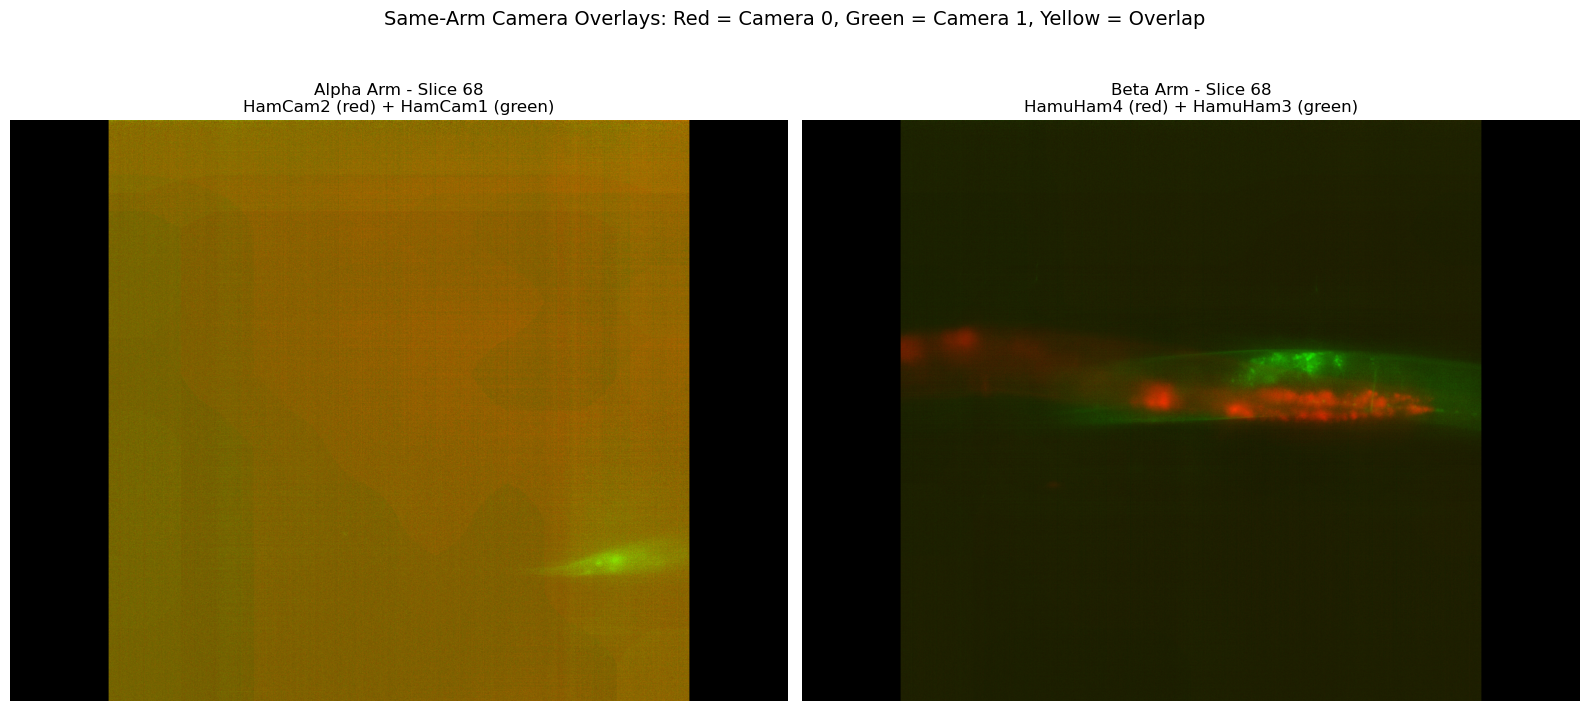

In [6]:
if selected_acq:
    # Select a slice in the middle of the volume
    slice_idx = alpha_cam0_deskewed.shape[0] // 2
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Alpha arm overlay (with horizontal flip to account for mirror images)
    alpha_overlay = create_camera_overlay(
        alpha_cam0_deskewed[slice_idx, :, :],
        alpha_cam1_deskewed[slice_idx, :, :],
        flip_cam2_horizontal=True,  # Account for mirror image relationship
    )
    axes[0].imshow(alpha_overlay, aspect='equal')
    axes[0].set_title(f'Alpha Arm - Slice {slice_idx}\n{alpha_meta["channel_names"][0]} (red) + {alpha_meta["channel_names"][1]} (green)', fontsize=12)
    axes[0].axis('off')
    
    # Beta arm overlay (with horizontal flip to account for mirror images)
    beta_overlay = create_camera_overlay(
        beta_cam0_deskewed[slice_idx, :, :],
        beta_cam1_deskewed[slice_idx, :, :],
        flip_cam2_horizontal=True,  # Account for mirror image relationship
    )
    axes[1].imshow(beta_overlay, aspect='equal')
    axes[1].set_title(f'Beta Arm - Slice {slice_idx}\n{beta_meta["channel_names"][0]} (red) + {beta_meta["channel_names"][1]} (green)', fontsize=12)
    axes[1].axis('off')
    
    plt.suptitle('Same-Arm Camera Overlays: Red = Camera 0, Green = Camera 1, Yellow = Overlap', fontsize=14)
    plt.tight_layout()
    plt.show()

### Stitched Camera Views: Full Sample Images

Stitch same camera index from both arms side-by-side to create full sample views.
For Camera 1 (second camera), the beta slice is horizontally flipped before stitching.


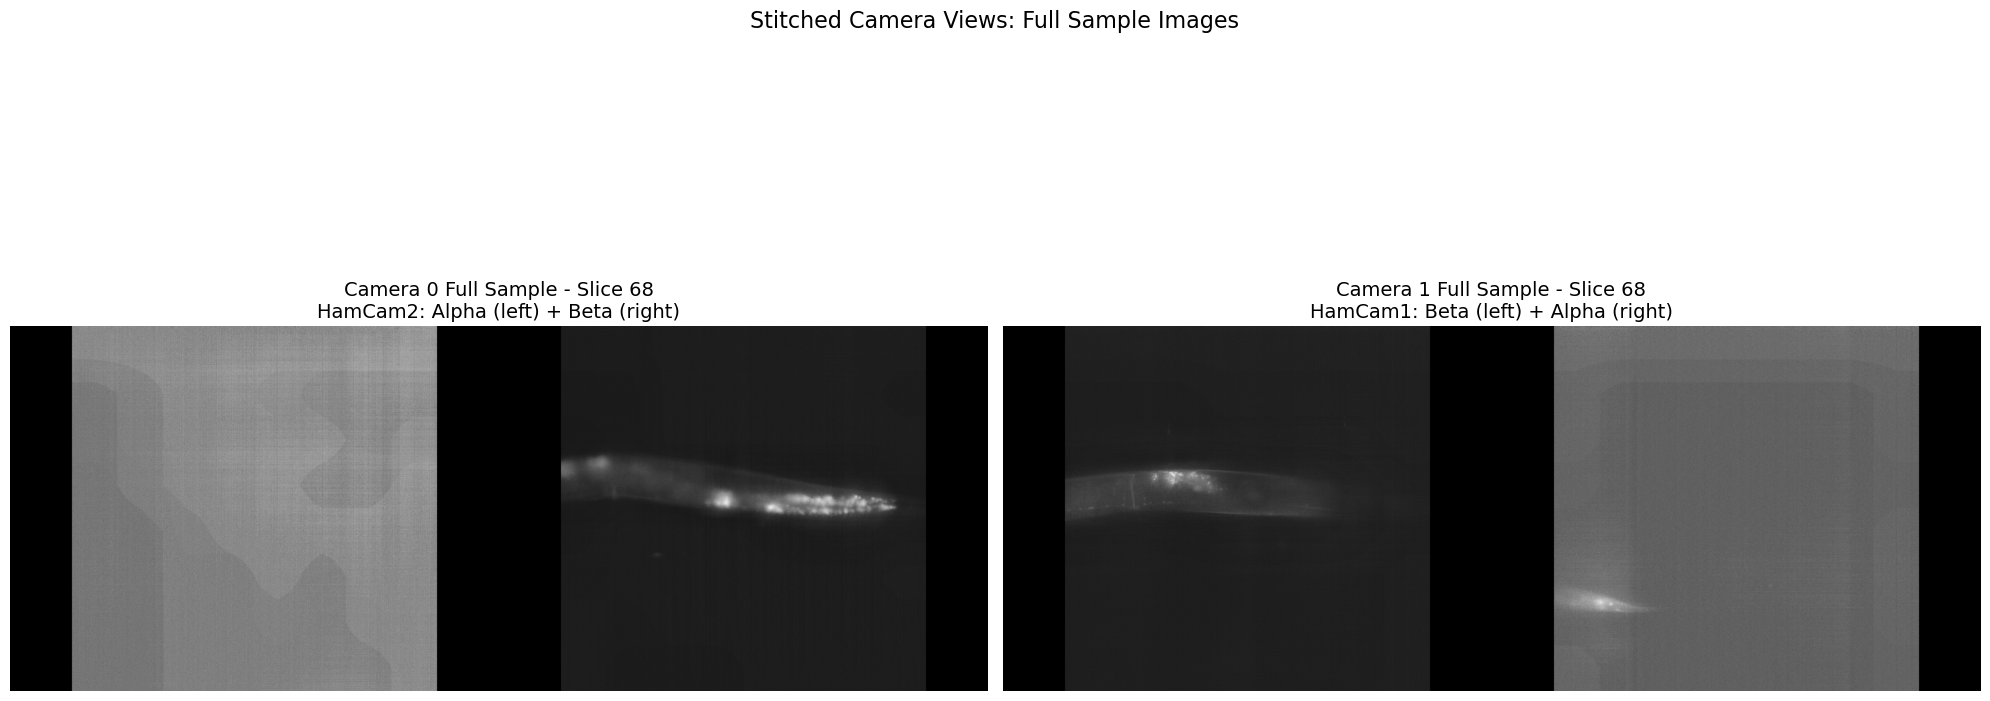

In [7]:
if selected_acq:
    slice_idx = alpha_cam0_deskewed.shape[0] // 2
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Camera 0: Stitched view (alpha left, beta right)
    stitched_cam0 = create_stitched_camera_view(
        alpha_cam0_deskewed[slice_idx, :, :],
        beta_cam0_deskewed[slice_idx, :, :],
        camera_index=0,  # Camera 0: alpha left, beta right
    )
    axes[0].imshow(stitched_cam0, cmap='gray', vmin=0, vmax=1, aspect='equal')
    axes[0].set_title(f'Camera 0 Full Sample - Slice {slice_idx}\n{alpha_meta["channel_names"][0]}: Alpha (left) + Beta (right)', fontsize=14)
    axes[0].axis('off')
    
    # Camera 1: Stitched view (alpha right, beta left, no flip)
    stitched_cam1 = create_stitched_camera_view(
        alpha_cam1_deskewed[slice_idx, :, :],
        beta_cam1_deskewed[slice_idx, :, :],
        camera_index=1,  # Camera 1: alpha right, beta left (reversed order)
    )
    axes[1].imshow(stitched_cam1, cmap='gray', vmin=0, vmax=1, aspect='equal')
    axes[1].set_title(f'Camera 1 Full Sample - Slice {slice_idx}\n{alpha_meta["channel_names"][1]}: Beta (left) + Alpha (right)', fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle('Stitched Camera Views: Full Sample Images', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No acquisition selected")


## Summary

### Processing Complete!

The pipeline has:
1. ✅ **Loaded Metadata**: Parsed acquisition parameters and timing information
2. ✅ **Temporally Aligned**: Loaded all 4 cameras with proper temporal alignment
3. ✅ **Deskewed**: Removed 45° shear from all 4 camera stacks
4. ✅ **Saved Volumes**: All deskewed volumes saved to `processed_output/`

### Next Steps

- **Interactive 3D Alignment**: Use Napari to interactively align the volumes
  ```bash
  python view_volumes_napari.py
  ```
- **Load Volumes**: The deskewed volumes can be loaded in any 3D visualization tool

### Saved Files

All deskewed volumes are saved as OME-TIFF files in:
```
processed_output/{acquisition_name}/deskewed/
  - alpha_{camera0_name}_deskewed.tif
  - alpha_{camera1_name}_deskewed.tif
  - beta_{camera0_name}_deskewed.tif
  - beta_{camera1_name}_deskewed.tif
```

Each volume also has an associated JSON metadata file with transformation information.